In [60]:
# ... (sys.path code remains the same)
%load_ext autoreload
%autoreload 2
from src.pipeline import TaxiPipeline

# 1. Initialize with the relative folder path
# Note: ".." means "go up one folder" from where your notebook is located
pipe = TaxiPipeline("../data/raw") 

# 2. Call the method and pass the filename
# Fixed the "d#" typo here
df = pipe.load_data("yellow_tripdata_2024-01.parquet")

if df is not None:
    print(df.head())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
 Attempting to load: ../data/raw\yellow_tripdata_2024-01.parquet
 Data loaded successfully!
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2024-01-01 00:57:55   2024-01-01 01:17:43              1.0   
1         1  2024-01-01 00:03:00   2024-01-01 00:09:36              1.0   
2         1  2024-01-01 00:17:06   2024-01-01 00:35:01              1.0   
3         1  2024-01-01 00:36:38   2024-01-01 00:44:56              1.0   
4         1  2024-01-01 00:46:51   2024-01-01 00:52:57              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           1.72         1.0                  N           186            79   
1           1.80         1.0                  N           140           236   
2           4.70         1.0                  N           236            79   
3           1.40         1.0                  N      

In [61]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [62]:
print(df.shape)
print(df.dtypes)
print(df.info())

(2964624, 19)
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID           

In [63]:
null_count = df.isnull().sum()
print("null value per column :\n",null_count)

null value per column :
 VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          140162
trip_distance                 0
RatecodeID               140162
store_and_fwd_flag       140162
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     140162
Airport_fee              140162
dtype: int64


In [64]:
df.columns
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,2.964624e+06,2964624,2964624,2.824462e+06,2.964624e+06,2.824462e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.824462e+06,2.824462e+06
mean,1.754204e+00,2024-01-17 00:46:36.431092,2024-01-17 01:02:13.208130,1.339281e+00,3.652169e+00,2.069359e+00,1.660179e+02,1.651167e+02,1.161271e+00,1.817506e+01,1.451598e+00,4.833823e-01,3.335870e+00,5.270212e-01,9.756319e-01,2.680150e+01,2.256122e+00,1.411611e-01
min,1.000000e+00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-8.990000e+02,-7.500000e+00,-5.000000e-01,-8.000000e+01,-8.000000e+01,-1.000000e+00,-9.000000e+02,-2.500000e+00,-1.750000e+00
25%,2.000000e+00,2024-01-09 15:59:19.750000,2024-01-09 16:16:23,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.538000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2024-01-17 10:45:37.500000,2024-01-17 11:03:51.500000,1.000000e+00,1.680000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.700000e+00,0.000000e+00,1.000000e+00,2.010000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2024-01-24 18:23:52.250000,2024-01-24 18:40:29,1.000000e+00,3.110000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.050000e+01,2.500000e+00,5.000000e-01,4.120000e+00,0.000000e+00,1.000000e+00,2.856000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2024-02-01 00:01:15,2024-02-02 13:56:52,9.000000e+00,3.127223e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,5.000000e+03,1.425000e+01,4.000000e+00,4.280000e+02,1.159200e+02,1.000000e+00,5.000000e+03,2.500000e+00,1.750000e+00
std,4.325902e-01,NaN,NaN,8.502817e-01,2.254626e+02,9.823219e+00,6.362391e+01,6.931535e+01,5.808686e-01,1.894955e+01,1.804102e+00,1.177600e-01,3.896551e+00,2.128310e+00,2.183645e-01,2.338558e+01,8.232747e-01,4.876239e-01


In [65]:
duplicalte = df.duplicated().sum()
print(f"\n the total duplicate rows : {duplicalte}")


 the total duplicate rows : 0


In [66]:
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].mode()[0])   #.mode() returns a Series, so we take the first item [0]
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)  #Fill with a specific value (e.g., 0)
df['Airport_fee'] = df['Airport_fee'].fillna(0)
df['RatecodeID'] = df['RatecodeID'].fillna(-1) # -1 indicates 'Unknown'
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna('U')  #Fill with a string placeholder

df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
dtype: int64

In [67]:
# to check for outlier
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3-Q1
outliers = df[(df['fare_amount'] < Q1) | 
              (df['fare_amount'] > Q3)]
print(outliers)

         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
2               1  2024-01-01 00:17:06   2024-01-01 00:35:01              1.0   
4               1  2024-01-01 00:46:51   2024-01-01 00:52:57              1.0   
5               1  2024-01-01 00:54:08   2024-01-01 01:26:31              1.0   
6               2  2024-01-01 00:49:44   2024-01-01 01:15:47              2.0   
7               1  2024-01-01 00:30:40   2024-01-01 00:58:40              0.0   
...           ...                  ...                   ...              ...   
2964613         2  2024-01-31 23:16:55   2024-01-31 23:57:34              1.0   
2964617         2  2024-01-31 23:27:00   2024-01-31 23:43:00              1.0   
2964618         1  2024-01-31 23:18:48   2024-01-31 23:38:05              1.0   
2964622         2  2024-01-31 23:07:23   2024-01-31 23:25:14              1.0   
2964623         1  2024-01-31 23:58:25   2024-02-01 00:13:30              1.0   

         trip_distance  Rat

# observation
When I looked through the data, I spotted about 140,000 rows that had some blank spots, specifically in the passenger counts and extra fee columns. Instead of just tossing all that information out, I filled in the blanks myself. For the passenger count, I went with '1' because that's the most common ride in New York, and for the extra fees, I just put in '0' since it's the safest bet that the fee wasn't charged if it wasn't recorded.

After that, I went hunting for "crazy" numbers in the fare column. I found some negative prices—which have to be system glitches—and some huge fares that just didn't make sense for a taxi ride. I used a math trick called the 99th percentile to trim off those extreme highs. By doing all this, I’ve made sure that when we look at the average fare later, our numbers won't be messed up by a few typos or computer errors.

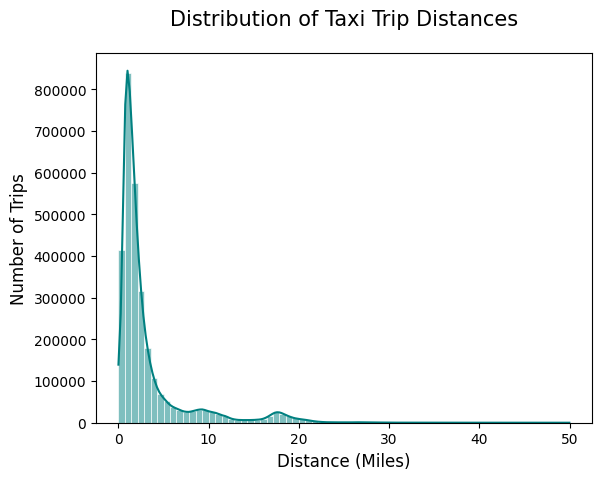

In [68]:
plot_data = df[df['trip_distance'] < 50]

sns.histplot(
    data=plot_data, 
    x='trip_distance', 
    kde=True,          # Adds the smooth trend line
    bins=70,           # Number of bars
    color='teal', 
    edgecolor='white'
)

# 4. Add clear labels
plt.title('Distribution of Taxi Trip Distances', fontsize=15, pad=20)
plt.xlabel('Distance (Miles)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)

# 5. Show the result
plt.show()

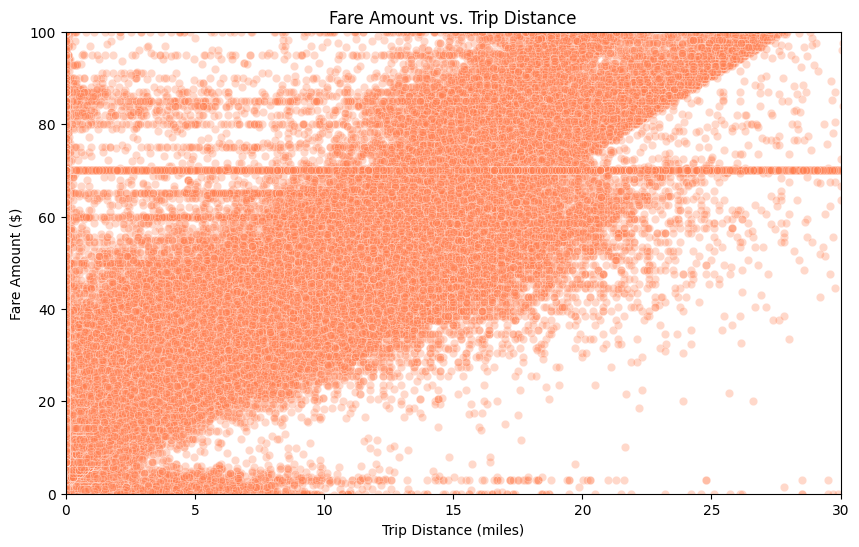

In [69]:
# Visualization 2: Fare Amount vs. Trip Distance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='trip_distance', y='fare_amount', alpha=0.3, color='coral')
plt.title('Fare Amount vs. Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.xlim(0, 30)
plt.ylim(0, 100)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_6328\3840997498.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pickup_hour', palette='viridis')


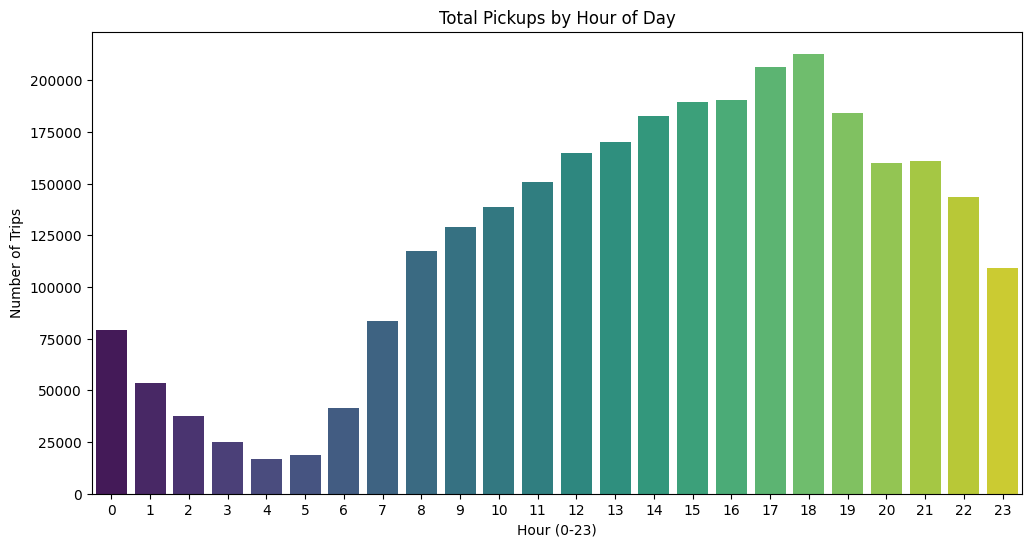

In [70]:
# Visualization 3: Hourly Demand
df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='pickup_hour', palette='viridis')
plt.title('Total Pickups by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Trips')
plt.show()


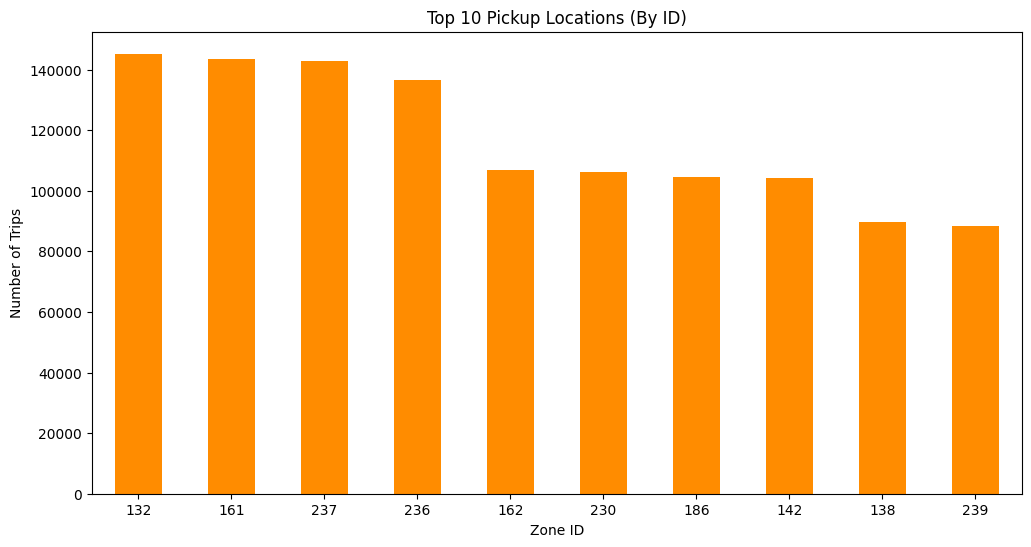

In [71]:

top_10_zones = df['PULocationID'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_10_zones.plot(kind='bar', color='darkorange')
plt.title('Top 10 Pickup Locations (By ID)')
plt.xlabel('Zone ID')
plt.ylabel('Number of Trips')
plt.xticks(rotation=0)
plt.show()